# Beam Tracking PPO

Tune the environment parameters below, run a quick rollout, train PPO, and inspect a deterministic evaluation rollout.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "beam_tracker_rl").exists():
    raise RuntimeError("Run this notebook from inside the beam_tracker_RL repository.")

sys.path.insert(0, str(PROJECT_ROOT))

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

import beam_tracker_rl
from beam_tracker_rl import ENV_ID, ChannelConfig, Obstacle, RewardConfig

try:
    from stable_baselines3 import PPO
    from stable_baselines3.common.monitor import Monitor
    SB3_AVAILABLE = True
except ImportError:
    SB3_AVAILABLE = False

SB3_AVAILABLE

True

In [2]:
ENV_KWARGS = dict(
    scenario_name="single_occluder",
    max_steps=192,
    hist_len=5,
    num_beams=13,
    obstacles=(Obstacle(x=470.0, y=220.0, w=84.0, h=140.0),),
    channel_config=ChannelConfig(
        snr_ref_db=30.0,
        path_loss_exp=2.2,
        blockage_loss_db=22.0,
        beam_3db_deg=10.0,
    ),
    reward_config=RewardConfig(
        outage_thresh_db=5.0,
        snr_weight=1.0,
        outage_weight=1.0,
        switch_weight=0.02,
    ),
)

TOTAL_TIMESTEPS = 100_000
SEED = 0

In [3]:
env = gym.make(ENV_ID, **ENV_KWARGS)
obs, info = env.reset(seed=SEED)
print(obs.shape, env.action_space, info)
env.close()

(11,) Discrete(13) {'t': 0, 'ue_xy': (128.0, 380.0), 'bs_xy': (512.0, 32.0), 'true_angle_deg': -47.81555668421123, 'selected_beam_idx': 1, 'selected_beam_deg': -50.0, 'distance': 518.2277491605404, 'blocked': False, 'snr_db': 13.707930277373178, 'beam_gain_db': -0.572615111987308, 'path_loss_db': 15.719454610639515, 'blockage_loss_db': 0.0, 'outage': False, 'reward': 0.0, 'events': {'beam_switched': False, 'occlusion_started': False, 'occlusion_ended': False, 'outage_started': False, 'outage_ended': False}, 'reward_terms': {'snr_term': 0.0, 'outage_penalty': 0.0, 'switch_penalty': 0.0, 'reward': 0.0}}


In [8]:
if not SB3_AVAILABLE:
    raise ImportError("Install PPO extras first: ./.venv/bin/python -m pip install -e '.[ppo]'")

train_env = Monitor(gym.make(ENV_ID, **ENV_KWARGS))
model = PPO(
    "MlpPolicy",
    train_env,
    seed=SEED,
    verbose=0,
    n_steps=1024,
    batch_size=256,
    learning_rate=3e-4,
    gamma=0.99,
)
model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=False)
train_env.close()


/home/narend/code/beam_tracker_RL/.venv/lib/python3.14/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [9]:
eval_env = gym.make(ENV_ID, **ENV_KWARGS)
obs, info = eval_env.reset(seed=SEED)
terminated = truncated = False
total_reward = 0.0

while not (terminated or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(int(action))
    total_reward += reward

log = eval_env.unwrapped.get_episode_log()
eval_env.close()

snr = np.array([row["snr_db"] for row in log])
blocked = np.array([row["blocked"] for row in log], dtype=float)
outage = np.array([row["outage"] for row in log], dtype=float)
actions = np.array([row["selected_beam_idx"] for row in log])

print(f"reward={total_reward:.3f} mean_snr={snr.mean():.3f} outage_rate={outage.mean():.3f}")

reward=-203.962 mean_snr=-7.783 outage_rate=0.661


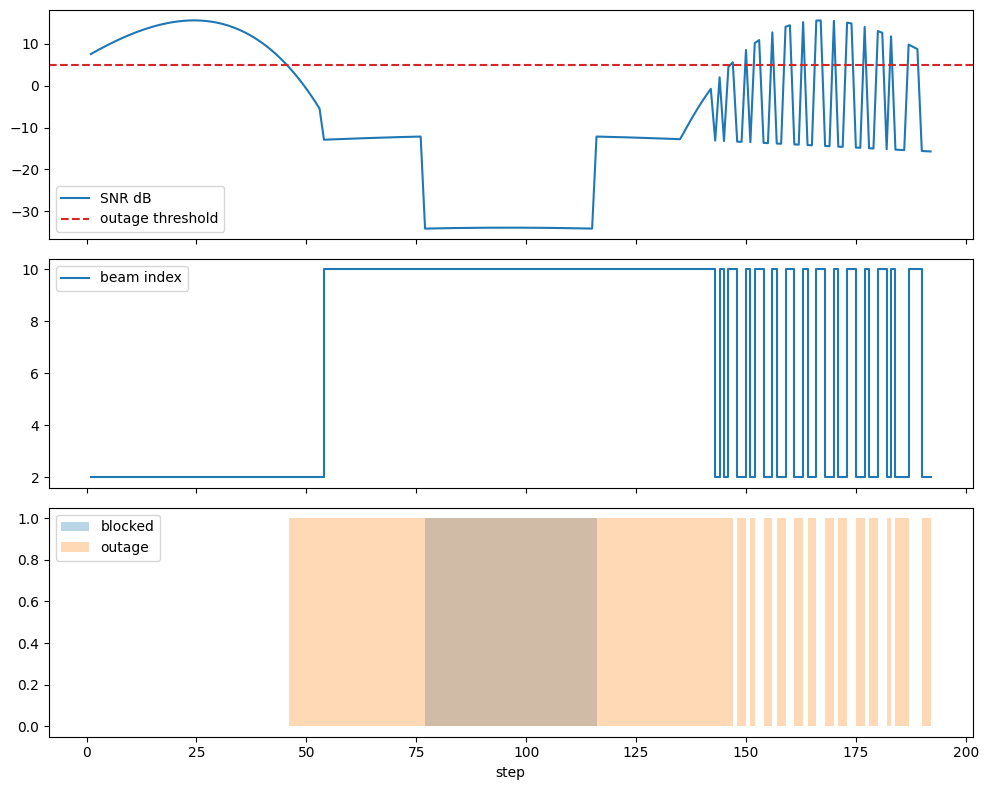

In [10]:
steps = np.arange(1, len(log) + 1)
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(steps, snr, label="SNR dB")
axes[0].axhline(ENV_KWARGS["reward_config"].outage_thresh_db, linestyle="--", color="tab:red", label="outage threshold")
axes[0].legend()

axes[1].step(steps, actions, where="post", label="beam index")
axes[1].legend()

axes[2].fill_between(steps, blocked, step="post", alpha=0.3, label="blocked")
axes[2].fill_between(steps, outage, step="post", alpha=0.3, label="outage")
axes[2].set_xlabel("step")
axes[2].legend()

fig.tight_layout()